# Write Code to load data
Will later on be put into production as code in a .py file

Here it is to write and experiment with the code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import socket as socket
import os as os
import sys as sys
import multiprocessing as mp
import warnings
import itertools as it

socket_name = socket.gethostname()
print(sys.version)
    
if socket_name.startswith("bionc") or socket_name.startswith("hpc"):
    print("Leipzig Cluster detected!")
    path = "/mnt/archgen/users/hringbauer/git/medieval/"   
else: 
    raise RuntimeWarning("Not compatible machine. Check!!")

sys.path.append("/mnt/archgen/users/hringbauer/git/EPIDEMIC/")
#sys.path.append("/mnt/archgen/users/hringbauer/git/projectPCA/projectPCA/")
sys.path.insert(0, "/mnt/archgen/users/hringbauer/git/projectPCA/")
     
os.chdir(path)  # Set the right Path (in line with Atom default)
print(os.getcwd())
print(f"CPU Count: {mp.cpu_count()}")
print(sys.version_info)

from ancIBD.ibd_stats.funcs import new_columns, give_sub_df, remove_iids # To manipulate PMR tables
from python.eigenstrat_funcs import load_genos_autoeager, pw_mm_rate, pw_mm_rates_iids, calc_r

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]
Leipzig Cluster detected!
/mnt/archgen/users/hringbauer/git/medieval
CPU Count: 128
sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)


# 1) Code to load PLINK data

In [8]:
from bed_reader import open_bed

In [9]:
%%time

bed = open_bed(path_plink_files)

# Number of individuals and SNPs
print("Individuals:", bed.iid_count)
print("SNPs:", bed.sid_count)

Individuals: 335
SNPs: 5811803
CPU times: user 144 ms, sys: 61.2 ms, total: 205 ms
Wall time: 220 ms


## Test the implemented loading object

In [5]:
### To test 
from projectPCA.loadEigenstrat import get_eigenstrat_object

### Test the class

In [6]:
%%time
es = get_eigenstrat_object(base_path="/mnt/archgen/users/hringbauer/git/EPIDEMIC/output/plink/bd_ptn_335", verbose=True,
                          mode="plink")

Loaded Genotype File set with 335 Individuals and 5811803 SNPs.
CPU times: user 8.55 s, sys: 5.18 s, total: 13.7 s
Wall time: 13.7 s


### Load Genotype of IID

In [7]:
%%time
g = es.get_geno_iid("PTN222")

CPU times: user 16.4 s, sys: 40.1 s, total: 56.5 s
Wall time: 29.6 s


In [8]:
np.shape(g)

(1, 5811803)

In [9]:
np.shape(g)[1]

5811803

In [ ]:
gt = np.array([es.get_geno_iid(iid) for iid in iids], dtype="float16")

# 2) Test PCA projection

In [2]:
from projectPCA.run import project_eigenstrat

### 2a) Baseline (Autoeager version)

In [4]:
%%time
project_eigenstrat(es_path="/mnt/archgen/Autorun_eager/eager_outputs/SG/PTN/PTN039/genotyping/pileupcaller.single",
                   pca="EU", es_type="autoeager",  plot=['pc2', 'pc1'], plot_bgrd_c=True, verbose=True)

Getting SNP weights...
Getting PCs...
Getting es object...
3 Eigenstrat Files with 1 Individuals and 1233013 SNPs
Running PCA projection...
Loading df_ind...
Loading df_snp...
Loading SNP df with 1233013 SNPs.
Loading Genotypes...


TypeError: list indices must be integers or slices, not str

Getting SNP weights...
Getting PCs...
Getting es object...
Loaded Genotype File set with 335 Individuals and 5811803 SNPs.
Running PCA projection...
Loading df_ind...
Loading df_snp...
Loading SNP df with 5811803 SNPs.
Loading Genotypes...
Loaded genotype matrix (1, 5811803).
Running PCA projection...
Matching: 388647. Matching flip: 0 of 388647.
Filtering 23037 / 388647 SNPs with MAF<0.05.


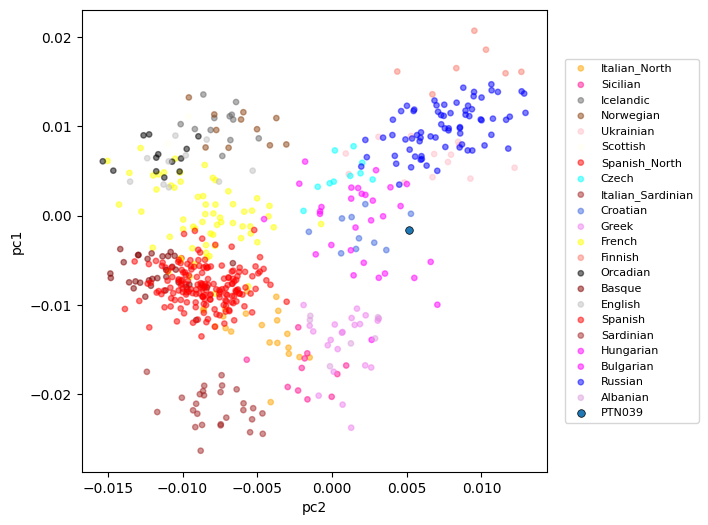

CPU times: user 27.2 s, sys: 43.8 s, total: 1min 10s
Wall time: 48.8 s


,pc1,pc2,#SNP,iid
0,-0.001625,0.005132,388647,PTN039


In [8]:
%%time
project_eigenstrat(es_path="/mnt/archgen/users/hringbauer/git/EPIDEMIC/output/plink/bd_ptn_335",
                   pca="EU", es_type="plink",  plot=['pc2', 'pc1'], iids=["PTN039"],
                   plot_bgrd_c=True, verbose=True, flip=True)

### Project all iids from PLINK

# Area 51

In [5]:
from bed_reader import open_bed

In [6]:
%%time

bed = open_bed("/mnt/archgen/users/hringbauer/git/EPIDEMIC/output/plink/bd_ptn_335.bed")

CPU times: user 2.38 ms, sys: 1.41 ms, total: 3.79 ms
Wall time: 9.67 ms


In [7]:
%%time
g = bed.read(np.s_[0,:])

CPU times: user 12.1 s, sys: 26.7 s, total: 38.7 s
Wall time: 22 s


In [8]:
print("test")

test


In [10]:
np.shape(g[0])

(5811803,)

In [12]:
g[0]


array([2., 2., 2., ..., 2., 2., 2.], shape=(5811803,), dtype=float32)